In [1]:
# Press Release mock image ROSALIA
# Alejandro Borlaff - NASA Ames Research Center
# a.s.borlaff@nasa.gov - August 5, 2026

# Plan: 
# Make a mock exposure object. 
# Run stray-light model. 

import rosalia as rs 
from astropy.time import Time
import os
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
os.chdir("/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK")

In [2]:
# CAR171: OUT_pos_1_a_013 
# RA 88.23938768241827 DEC -48.53277317761877 PA 98.22514198825647 

# Let's define the minimum parameters to generate a dummy Roman / WFI image
# To get some challenging environment, let's target the Pleiades.
ra = 88.23938768241827  # Right ascension, in degrees. 
dec = -48.53277317761877  # Declination, in degrees.
PA = 98.22514198825647  # Position angle, in degrees.
date = Time('2026-12-01T00:00:00.0', format='isot', scale='utc')
bandpass = "F184" # "F129"# "F087" # Z087 J129 F184
exptime = 193 # Exposure time, in seconds.


observer={"TELESCOP": "Roman/WFI", 
          "pointing": [ra, dec], 
          "FILTER":bandpass, 
          "PA_Y": PA, 
          "EXPSTART": date.mjd, 
          "EXPTIME": exptime}

prefix = "PR_mock_" + bandpass
g_mag_max = 15

In [3]:
custom_roman_exposure = rs.core.exposure(observer=observer, prefix=prefix) 


> roman_wfi_exposure


2026-08-14T15:43:46.878137 > Fetching catalog


18it [00:03,  5.06it/s]

2026-08-14T15:43:50.972198 > Done.
2026-08-14T15:43:50.979953 > Starting Stray-light scan: 



100%|██████████| 18/18 [00:57<00:00,  3.19s/it]


2026-08-14T15:44:49.498645 > Done : 0:00:58.519012 elapsed.
 > Reconstructing the Stray-light / Main offender map: 
2026-08-14T15:44:50.547587 > Done : 


...

100%|██████████| 18/18 [01:57<00:00,  6.52s/it]


2026-08-14T15:48:30.952450 > Done
2026-08-14T15:48:30.953056 > Summary plots... 
Plot: Stray-light surface brightness magnitude.


2026-08-14 15:48:31 WARNING  findfont: Failed to find font weight normal, now using 500.


DEMO WARNING: make_stray_plot is Assuming F129.
25
35


2026-08-14 15:48:31 WARNING  findfont: Failed to find font weight normal, now using 500.


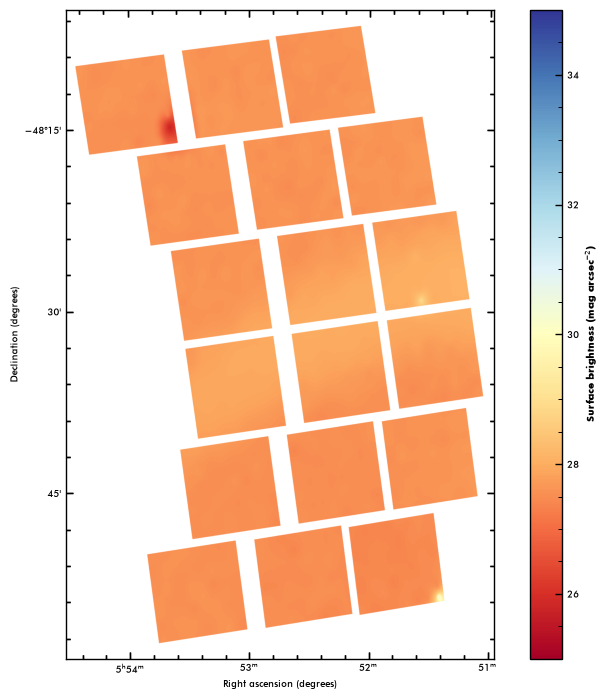

Plot: Stray-light surface brightness flux.
0.003078974002035134
0.00487268903910425


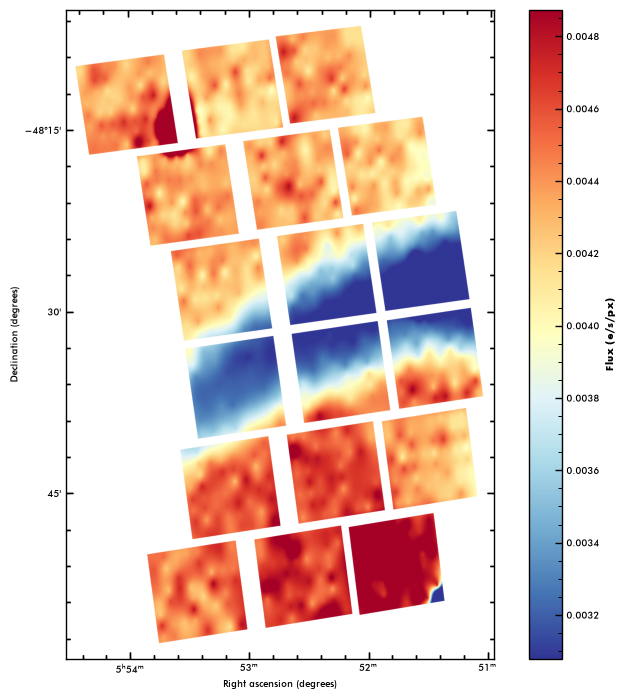

Plot: Main offender map.
7.0
44.0
Unique IDs:
[     7     44 137395 197091]
Unique IDs with counts > 1:
[     7     44 137395 197091]
V* R Dor
* alf Car
CD-48  2033


2026-08-14 15:48:38 WARNING  findfont: Failed to find font weight normal, now using 500.


UCAC4 209-006789
Main stray-light offenders:

87.47% - (95.99, -52.70), m=0.23 - * alf Car
12.09% - (69.19, -62.08), m=-2.38 - V* R Dor
0.35% - (88.39, -48.25), m=12.35 - UCAC4 209-006789
0.08% - (88.44, -48.78), m=7.41 - CD-48  2033


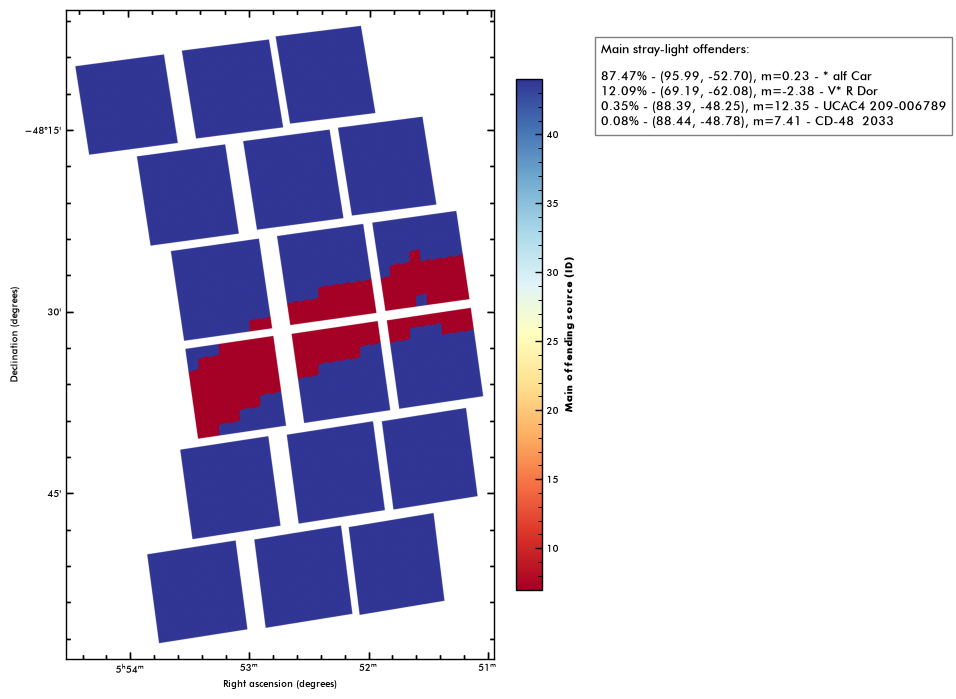

Plot: Source environment map.
SSO body: Sun not found. Skipping
SSO body: Moon not found. Skipping
SSO body: Earth not found. Skipping
SSO body: Mercury not found. Skipping
SSO body: Venus not found. Skipping
SSO body: Mars not found. Skipping
SSO body: Jupiter not found. Skipping
SSO body: Saturn not found. Skipping
SSO body: Uranus not found. Skipping
SSO body: Neptune not found. Skipping
SSO body: Pluto not found. Skipping


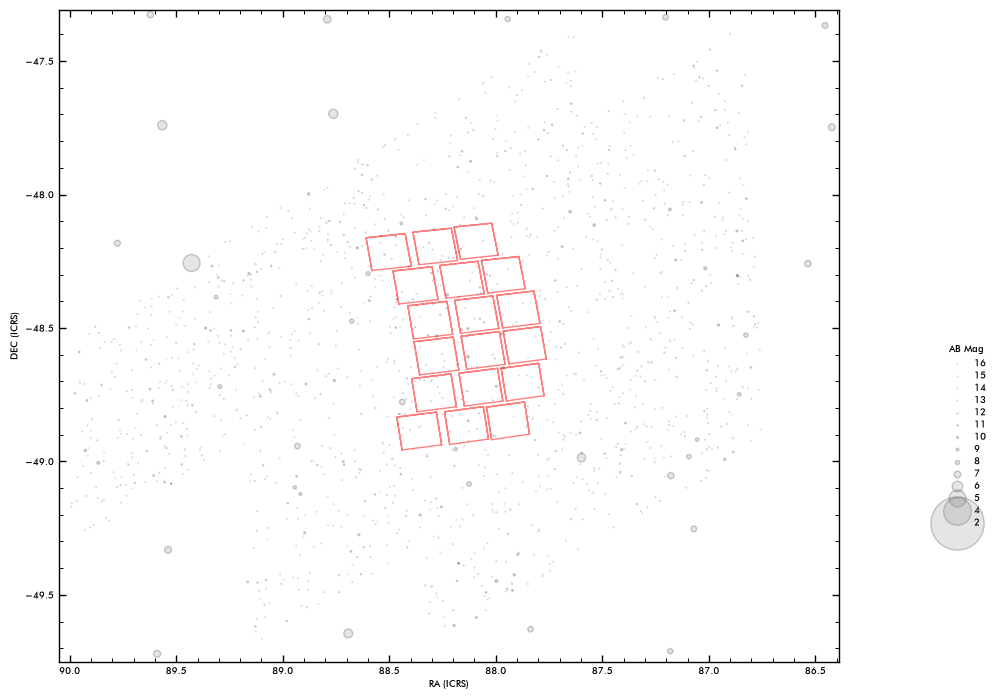

Plot: Location of Main offenders on NDI map.
Unique IDs:
[     7     44 137395 197091]
Unique IDs with counts > 1:
[     7     44 137395 197091]
V* R Dor
* alf Car
CD-48  2033
UCAC4 209-006789
Main stray-light offenders:

87.47% - (95.99, -52.70), m=0.23 - * alf Car
12.09% - (69.19, -62.08), m=-2.38 - V* R Dor
0.35% - (88.39, -48.25), m=12.35 - UCAC4 209-006789
0.08% - (88.44, -48.78), m=7.41 - CD-48  2033
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 88.23938768241827 -48.53277317761877
CRPIX : 636.5 636.5
NAXIS : 1273  1273


2026-08-14 15:48:41 WARNING  findfont: Failed to find font weight normal, now using 500.


2026-08-14T15:48:46.076564 > Done
Output saved in: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stray.fits
Report saved in: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stray.pdf


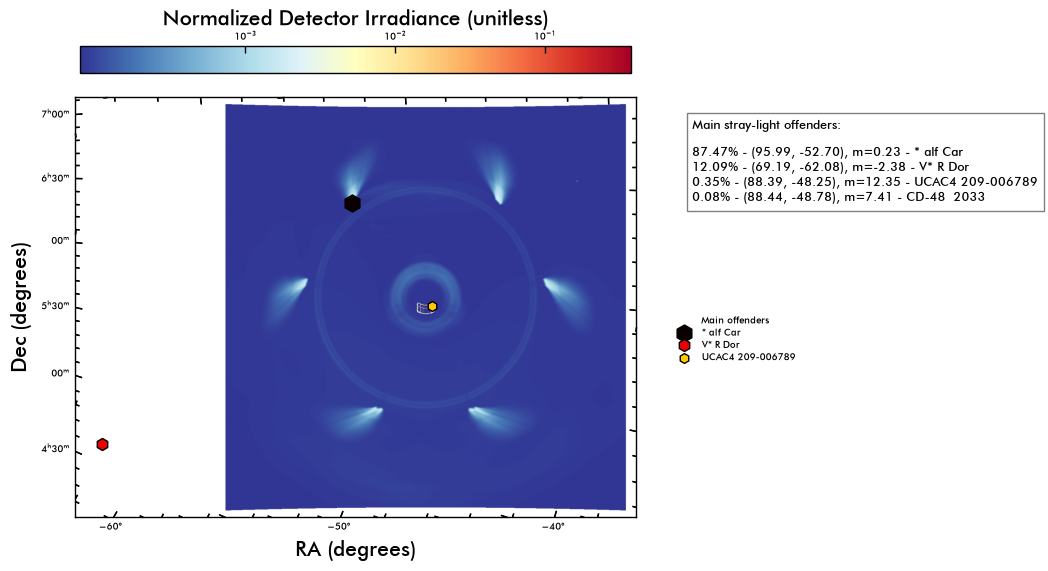

In [4]:
straylight_background = custom_roman_exposure.straylight(g_mag_max=g_mag_max)

In [5]:
# This notebook demonstrates how to use ROSALIA to analyze psf in a simple image. 
psf_background = custom_roman_exposure.psf_background(g_mag_max=g_mag_max, verbose=True)

TO DO: Make stamps with a more reasonable size. Dim stars can have smaller PSFs.
To do this, make a profile of the Roman / PSF, and find out when would it be essentially 0.
Generating stamps for infield stars...
We might need to get rid of stars very far away.
[246.94039    273.56662    207.33457    ...  87.33523845  89.69162884
  88.0112637 ]
(198258,)


  6%|▌         | 1/18 [00:00<00:06,  2.82it/s]

Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_01/star_ext01_id_000000.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_01/star_ext01_id_000001.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_01/star_ext01_id_000002.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_01/star_ext01_id_000003.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_01/star_ext01_id_000004.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks

 11%|█         | 2/18 [00:00<00:04,  3.34it/s]

Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_02/star_ext02_id_000000.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_02/star_ext02_id_000001.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_02/star_ext02_id_000002.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_02/star_ext02_id_000003.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_02/star_ext02_id_000004.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks

...

100%|██████████| 18/18 [00:05<00:00,  3.48it/s]

Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_18/star_ext18_id_000000.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_18/star_ext18_id_000001.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_18/star_ext18_id_000002.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_18/star_ext18_id_000003.fits
Star stamp already exists: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_star_stamps/SCIEXT_18/star_ext18_id_000004.fits


Storing stars in each SCA


100%|██████████| 18/18 [02:00<00:00,  6.69s/it]


In-field stray-light model completed. Level 2 multi-extension FITS: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stars.fits
Mosaic image: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stars_drz.fits
Scaled mosaic: /Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F184_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stars_drz_scaled.fits


In [ ]:
# Get the zodiacal light background 
drz_name = psf_background.replace("_stars.fits", "_stars_drz.fits")

drz_fits = fits.open(drz_name)
import astropy.wcs as astropy_wcs
wcs =  astropy_wcs.WCS(header=drz_fits[0].header, fobj=drz_fits, naxis=2)
import numpy as np
for filter_pablo in ["F062", "F129", "F158"]:
    FILTER_IDENTITY = rs.telescopes.find_filter_in_svo(wavelength=filter_pablo,
                                                                        telescope=custom_roman_exposure.TELESCOP,
                                                                        instrument=custom_roman_exposure.INSTRUME, 
                                                                        detector=custom_roman_exposure.DETECTOR, verbose=False)
    zodiacal_background = rs.sky.get_zodiacal_background(wcs,
                                                        wavelength=FILTER_IDENTITY,
                                                        telescope=custom_roman_exposure.TELESCOP,
                                                        instrument=custom_roman_exposure.INSTRUME,
                                                        detector=custom_roman_exposure.DETECTOR,
                                                        expstart=custom_roman_exposure.EXPSTART,
                                                        step=5000, zody_mode="zodipy",
                                                        nbins_wavelength=10, obslocin=0,
                                                        grid_method="random",
                                                        output_units="e/s",
                                                        verbose=False)

    zodiacal_background_es = zodiacal_background.value
    zodiacal_background_es[np.isnan(drz_fits[0].data)] = np.nan
    zodiacal_background_es[drz_fits[0].data==0] = np.nan

    rs.utils.save_fits(np.float32(zodiacal_background_es), drz_name.replace("_stars_", "_zody_" + filter_pablo + "_"), drz_fits[0].header)

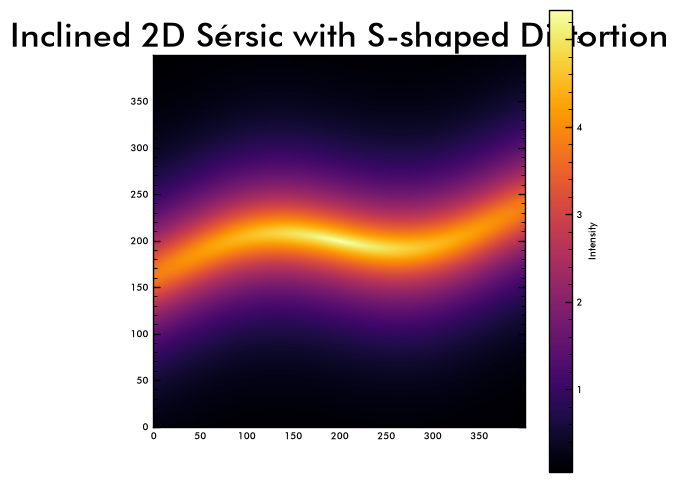

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling.models import Sersic2D

# Image grid
nx, ny = 400, 400
x = np.linspace(-200, 200, nx)
y = np.linspace(-200, 200, ny)
xx, yy = np.meshgrid(x, y)

# Sérsic parameters
amplitude = 1.0
r_eff = 1000.0
n = 1.0
x0, y0 = 0.0, 0.0

# Inclination as axis ratio q = cos(i)
inclination_deg = 85.0
q = np.cos(np.radians(inclination_deg))
ellip = 1 - q

# Position angle
pa_deg = 0.0
theta = np.radians(pa_deg)

# Base Sérsic model (no distortion)
sersic = Sersic2D(amplitude=amplitude,
                  r_eff=r_eff,
                  n=n,
                  x_0=x0,
                  y_0=y0,
                  ellip=ellip,
                  theta=theta)

# --- Apply S-shaped distortion ---
# S-shaped warp function
def s_warp(x, strength=0.2, scale=75):
    return strength * x * np.cos(x / scale)

# Warp coordinates
yy_warped = yy + s_warp(xx)  # add S-shape vertical displacement

# Evaluate Sérsic on warped coordinates
image = sersic(xx, yy_warped)

# Plot
plt.figure(figsize=(6,6))
plt.imshow(image, origin='lower', cmap='inferno')
plt.colorbar(label="Intensity")
plt.title("Inclined 2D Sérsic with S-shaped Distortion")
plt.show()